# Unidad 2: Aprendizaje Automático
## 📐 Reducción de Dimensionalidad con PCA
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

![Reducción de Dimensionalidad](https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/notebooks/ml/images/pexels-ivaivo-14869517.jpg)

[Foto de Ivaivo en Pexels](https://www.pexels.com/photo/14869517/)

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/unsupervised/03_PCA_DimensionalityReduction.ipynb)


## 🎯 ¿Qué vamos a aprender?

Imaginá que tenés datos con muchas variables (dimensiones): hay **redundancia** (variables correlacionadas), hay **ruido**, y cuesta visualizar. La idea de la reducción de dimensionalidad es **proyectar los datos a un espacio más pequeño que conserve lo importante**.

Al finalizar, vas a poder:
- ✅ Explicar intuitivamente para qué sirve la reducción de dimensionalidad
- ✅ Entender la matemática esencial detrás de PCA
- ✅ Aplicar PCA con scikit-learn correctamente (respetando el escalado previo)
- ✅ Elegir el número óptimo de componentes usando la varianza explicada acumulada
- ✅ Visualizar datos de alta dimensión en 2D y 3D
- ✅ Reconocer los errores más comunes y cómo evitarlos

---

## 🧠 Marco Teórico

### 1. Intuición: el "para qué"

Cuando tenés muchas variables, muchas de ellas **dicen cosas parecidas** (están correlacionadas). PCA encuentra **nuevas variables** (combinaciones de las originales) que:
- capturan la mayor variabilidad de los datos
- son ortogonales entre sí (independientes)
- se ordenan de mayor a menor varianza explicada

```
Datos originales (p dimensiones)  →  PCA  →  k dimensiones (k << p)
                                              conservando ~90-95% de la info
```

---

### 2. Matemática esencial

PCA busca **direcciones** $\mathbf{w}$ en las que los datos proyectados $\mathbf{Xw}$ tengan **máxima varianza**:

$$\underset{\mathbf{w}}{\max} \; \text{Var}(\mathbf{Xw})$$

**Cómo lo hace:**

1. **Centrar los datos**: $X_{cent} = X - \bar{X}$
2. **Calcular la matriz de covarianza**: $C = \frac{1}{n-1} X_{cent}^T X_{cent}$
3. **Descomposición espectral**: $C = V \Lambda V^T$
   - $V$: matriz de **autovectores** (nuevas direcciones = componentes principales)
   - $\Lambda$: diagonal con **autovalores** (varianza en cada dirección)
4. **Ordenar** componentes de mayor a menor autovalor

$$\text{Varianza explicada por PC}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

> 📌 **Propiedad clave:** las componentes principales son **combinaciones lineales** de las variables originales. No son variables interpretables directamente como las originales.

---

### 3. El problema de la maldición de la dimensionalidad

A medida que aumentan las dimensiones:
- El volumen del espacio crece exponencialmente
- Los datos se vuelven **escasos** (sparse)
- Las distancias pierden significado
- Los modelos requieren más datos para generalizar

PCA mitiga este problema conservando solo las dimensiones más informativas.

> 📌 **Referencias:**
> - [scikit-learn — Decomposition (PCA)](https://scikit-learn.org/stable/modules/decomposition.html#pca)
> - [scikit-learn — User Guide: Dimensionality Reduction](https://scikit-learn.org/stable/modules/unsupervised_reduction.html)

---


## 📦 Paso 1: Importar las Librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

SEED = 42
np.random.seed(SEED)

print('✅ Librerías importadas correctamente!')


✅ Librerías importadas correctamente!


## 🌸 Paso 2: Cargar y Explorar el Dataset

Usamos **Iris** (4 features, 3 clases) para comenzar: es suficientemente simple para entender los conceptos, y suficientemente real para que los resultados sean interesantes.


In [10]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print('🌸 Dataset Iris:')
print(f'  Forma: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} features')
print(f'  Clases: {list(iris.target_names)}')
print()
print('📊 Estadísticas descriptivas:')
print(X.describe().round(6))
print()
print('📌 Nota: las features tienen escalas distintas.')
print('   sepal length: media ~5.8   vs  petal width: media ~1.2')
print('   → ESCALAR antes de PCA es obligatorio.')


🌸 Dataset Iris:
  Forma: (150, 4)  →  150 muestras, 4 features
  Clases: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

📊 Estadísticas descriptivas:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

📌 Nota: las

## ⚠️ Paso 3: El Error Más Común — No Escalar

Antes de aplicar PCA, **siempre escalar**. Si no lo hacés, las features con valores grandes (ej: `sepal length` ~5–8 cm) dominarán las componentes artificialmente, sin importar si son más informativas o no.

Comparamos el resultado con y sin estandarización.


Varianza explicada por las primeras 2 componentes:
  ❌ Sin escalar: PC1=92.5%  PC2=5.3%  Total=97.8%
  ✅ Con escalado: PC1=73.0%  PC2=22.9%  Total=95.8%


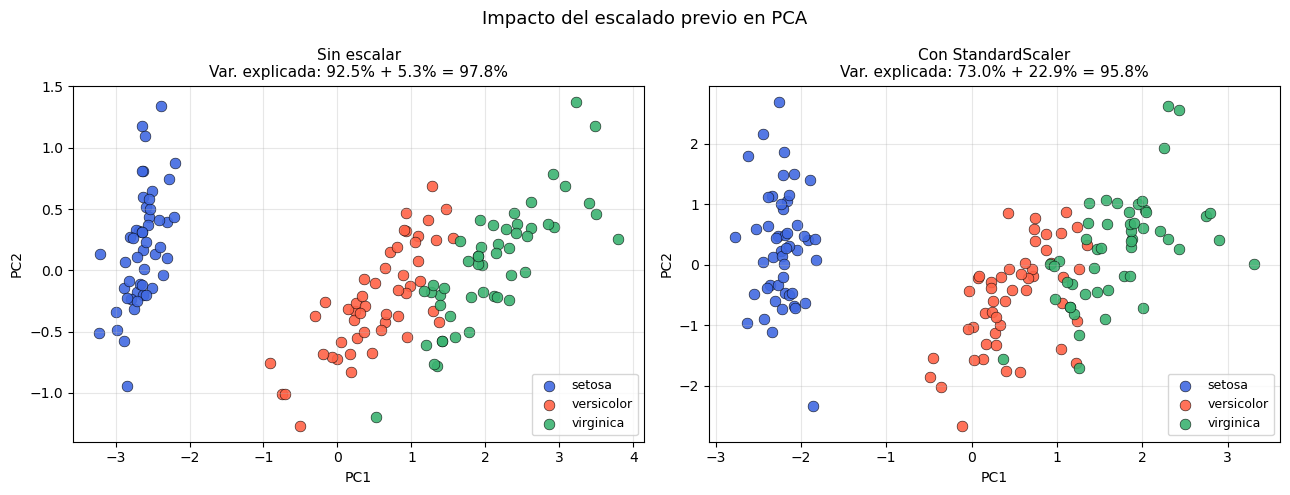


💡 Con escalado, las clases quedan mejor separadas y se captura más varianza relevante.


In [3]:
X_vals = X.values

# ❌ PCA sin escalar
pca_sin_esc = PCA(n_components=2)
X_pca_sin   = pca_sin_esc.fit_transform(X_vals)

# ✅ PCA con StandardScaler (correcto)
X_scaled = StandardScaler().fit_transform(X_vals)
pca_con_esc = PCA(n_components=2)
X_pca_con   = pca_con_esc.fit_transform(X_scaled)

# Comparación de varianza explicada
print('Varianza explicada por las primeras 2 componentes:')
print(f'  ❌ Sin escalar: PC1={pca_sin_esc.explained_variance_ratio_[0]*100:.1f}%'
      f'  PC2={pca_sin_esc.explained_variance_ratio_[1]*100:.1f}%'
      f'  Total={sum(pca_sin_esc.explained_variance_ratio_)*100:.1f}%')
print(f'  ✅ Con escalado: PC1={pca_con_esc.explained_variance_ratio_[0]*100:.1f}%'
      f'  PC2={pca_con_esc.explained_variance_ratio_[1]*100:.1f}%'
      f'  Total={sum(pca_con_esc.explained_variance_ratio_)*100:.1f}%')

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto del escalado previo en PCA', fontsize=13)

colores = ['royalblue', 'tomato', 'mediumseagreen']
for i, nombre in enumerate(iris.target_names):
    mask = y == i
    axes[0].scatter(X_pca_sin[mask, 0], X_pca_sin[mask, 1],
                    c=colores[i], label=nombre, s=60,
                    edgecolors='black', linewidths=0.4, alpha=0.9)
    axes[1].scatter(X_pca_con[mask, 0], X_pca_con[mask, 1],
                    c=colores[i], label=nombre, s=60,
                    edgecolors='black', linewidths=0.4, alpha=0.9)

for ax, titulo, var in zip(axes,
        ['Sin escalar', 'Con StandardScaler'],
        [pca_sin_esc.explained_variance_ratio_, pca_con_esc.explained_variance_ratio_]):
    ax.set_title(f'{titulo}\nVar. explicada: {var[0]*100:.1f}% + {var[1]*100:.1f}% = {sum(var)*100:.1f}%',
                 fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\n💡 Con escalado, las clases quedan mejor separadas y se captura más varianza relevante.')


## 📊 Paso 4: Varianza Explicada — ¿Cuántas Componentes Usar?

La pregunta clave al aplicar PCA es: **¿cuántas componentes retengo?**

La respuesta práctica: elegir el número de componentes donde la **varianza acumulada** alcanza ~90–95%.

Usaremos el dataset **Breast Cancer** (30 features) para que sea más ilustrativo.


In [4]:
cancer = load_breast_cancer()
X_bc   = StandardScaler().fit_transform(cancer.data)
y_bc   = cancer.target

# PCA completo (tantas componentes como features)
pca_full = PCA().fit(X_bc)

var_individual  = pca_full.explained_variance_ratio_
var_acumulada   = np.cumsum(var_individual)

# Dónde se cruzan los umbrales
umbral_90 = np.argmax(var_acumulada >= 0.90) + 1
umbral_95 = np.argmax(var_acumulada >= 0.95) + 1

print(f'🔬 Dataset Breast Cancer: {cancer.data.shape[0]} muestras, {cancer.data.shape[1]} features')
print()
print('📊 Varianza acumulada:')
for i in [1, 2, 3, 4, 5, 10, 15, 20]:
    print(f'  {i:2d} componentes → {var_acumulada[i-1]*100:.1f}%')
print()
print(f'  → Para capturar ≥90% se necesitan {umbral_90} componentes')
print(f'  → Para capturar ≥95% se necesitan {umbral_95} componentes')
print(f'  → Reducción: {cancer.data.shape[1]} → {umbral_95} features  '
      f'({(1 - umbral_95/cancer.data.shape[1])*100:.0f}% menos)')


🔬 Dataset Breast Cancer: 569 muestras, 30 features

📊 Varianza acumulada:
   1 componentes → 44.3%
   2 componentes → 63.2%
   3 componentes → 72.6%
   4 componentes → 79.2%
   5 componentes → 84.7%
  10 componentes → 95.2%
  15 componentes → 98.6%
  20 componentes → 99.6%

  → Para capturar ≥90% se necesitan 7 componentes
  → Para capturar ≥95% se necesitan 10 componentes
  → Reducción: 30 → 10 features  (67% menos)


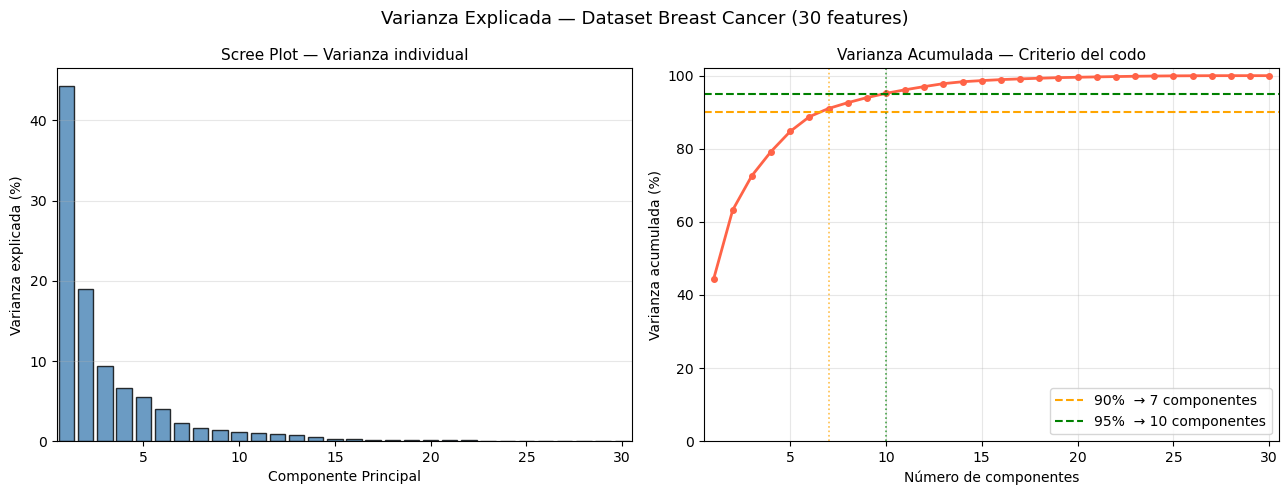

💡 El "codo" del scree plot indica dónde se estabiliza la ganancia de varianza.
   Con solo 10 de las 30 features originales capturamos el 95% de la información.


In [5]:
# Gráfico del "codo": varianza individual + acumulada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Varianza Explicada — Dataset Breast Cancer (30 features)', fontsize=13)

n = len(var_individual)

# Panel izquierdo: varianza individual (scree plot)
ax = axes[0]
ax.bar(range(1, n + 1), var_individual * 100, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Scree Plot — Varianza individual', fontsize=11)
ax.set_xlim(0.5, n + 0.5)
ax.grid(True, axis='y', alpha=0.3)

# Panel derecho: varianza acumulada
ax = axes[1]
ax.plot(range(1, n + 1), var_acumulada * 100,
        marker='o', markersize=4, color='tomato', linewidth=2)
ax.axhline(90, color='orange', linestyle='--', linewidth=1.5,
           label=f'90%  → {umbral_90} componentes')
ax.axhline(95, color='green', linestyle='--', linewidth=1.5,
           label=f'95%  → {umbral_95} componentes')
ax.axvline(umbral_90, color='orange', linestyle=':', linewidth=1.2, alpha=0.7)
ax.axvline(umbral_95, color='green',  linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada (%)')
ax.set_title('Varianza Acumulada — Criterio del codo', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0.5, n + 0.5)
ax.set_ylim(0, 102)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('💡 El "codo" del scree plot indica dónde se estabiliza la ganancia de varianza.')
print(f'   Con solo {umbral_95} de las {n} features originales capturamos el 95% de la información.')


## 👁️ Paso 5: Visualización en 2D y 3D

Una de las aplicaciones más útiles de PCA es poder **visualizar** datos de alta dimensión. Reducimos Iris (4D) y Breast Cancer (30D) a 2 y 3 componentes.


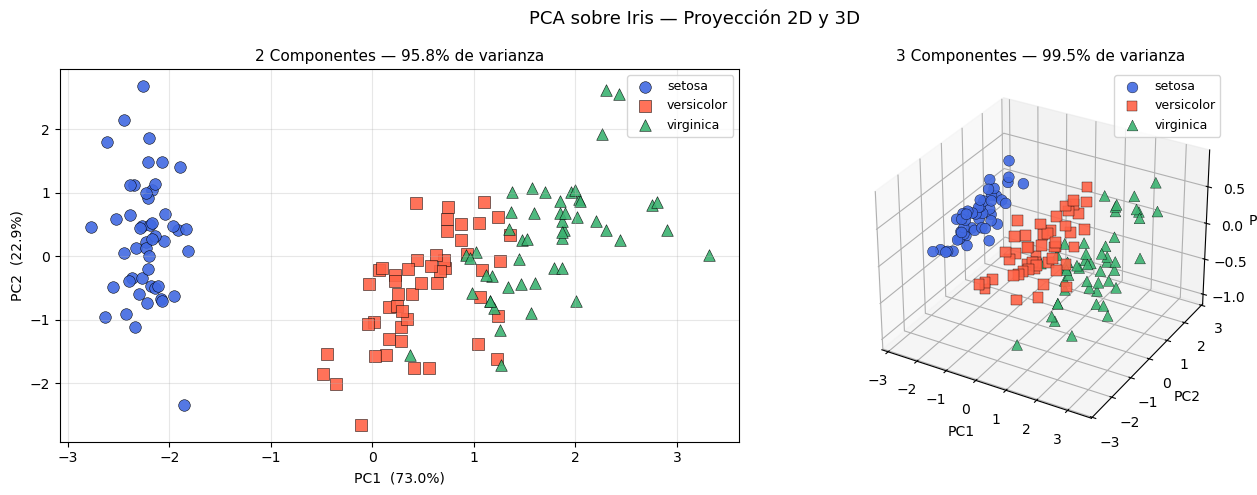

💡 Setosa (azul) es linealmente separable. Versicolor y Virginica se solapan levemente.


In [6]:
# ── Iris: 4D → 2D y 3D ──
pca2 = PCA(n_components=2)
pca3 = PCA(n_components=3)
X_iris2 = pca2.fit_transform(X_scaled)
X_iris3 = pca3.fit_transform(X_scaled)

colores_iris = ['royalblue', 'tomato', 'mediumseagreen']
formas_iris  = ['o', 's', '^']

fig = plt.figure(figsize=(14, 5))
fig.suptitle('PCA sobre Iris — Proyección 2D y 3D', fontsize=13)

# Panel 2D
ax2 = fig.add_subplot(121)
for i, nombre in enumerate(iris.target_names):
    mask = y == i
    ax2.scatter(X_iris2[mask, 0], X_iris2[mask, 1],
                c=colores_iris[i], marker=formas_iris[i],
                label=nombre, s=70, edgecolors='black', linewidths=0.4, alpha=0.9)
ax2.set_title(f'2 Componentes — '
              f'{sum(pca2.explained_variance_ratio_)*100:.1f}% de varianza', fontsize=11)
ax2.set_xlabel(f'PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3D
ax3 = fig.add_subplot(122, projection='3d')
for i, nombre in enumerate(iris.target_names):
    mask = y == i
    ax3.scatter(X_iris3[mask, 0], X_iris3[mask, 1], X_iris3[mask, 2],
                c=colores_iris[i], marker=formas_iris[i],
                label=nombre, s=60, edgecolors='black', linewidths=0.3, alpha=0.9)
ax3.set_title(f'3 Componentes — '
              f'{sum(pca3.explained_variance_ratio_)*100:.1f}% de varianza', fontsize=11)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('💡 Setosa (azul) es linealmente separable. Versicolor y Virginica se solapan levemente.')


## 🔍 Paso 6: Interpretación de las Componentes

¿Qué significa cada componente principal? Las componentes son **combinaciones lineales** de las features originales. Los **loadings** (coeficientes) nos dicen cuánto contribuye cada feature original a cada componente.

> ⚠️ Las componentes no tienen un nombre intuitivo como las features originales. La interpretación depende del dominio y del signo/magnitud de los loadings.


📊 Loadings de PCA — Iris (datos escalados):
   (cuánto contribuye cada feature original a cada componente)

             PC1    PC2    PC3    PC4
sepal len  0.521  0.377  0.720 -0.261
sepal wid -0.269  0.923 -0.244  0.124
petal len  0.580  0.024 -0.142  0.801
petal wid  0.565  0.067 -0.634 -0.524

📊 Varianza explicada por componente:
  PC1: 73.0%
  PC2: 22.9%
  PC3: 3.7%
  PC4: 0.5%


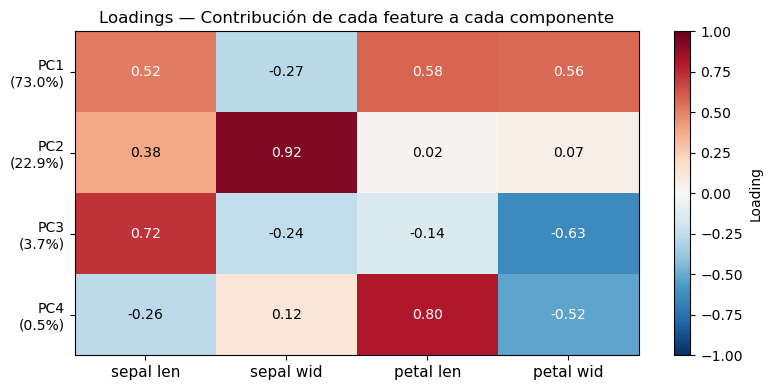


💡 Interpretación aproximada:
   PC1: "tamaño del pétalo" → petal len y petal wid con loadings altos positivos
   PC2: "forma del sépalo" → sepal wid dominante
   ⚠️  Estas interpretaciones son orientativas, no literales.


In [7]:
# Loadings: contribución de cada feature a cada componente
pca4 = PCA(n_components=4).fit(X_scaled)

feature_names_short = ['sepal len', 'sepal wid', 'petal len', 'petal wid']
loadings = pd.DataFrame(
    pca4.components_.T,
    index=feature_names_short,
    columns=[f'PC{i+1}' for i in range(4)]
).round(3)

print('📊 Loadings de PCA — Iris (datos escalados):')
print('   (cuánto contribuye cada feature original a cada componente)')
print()
print(loadings)
print()
print('📊 Varianza explicada por componente:')
for i, v in enumerate(pca4.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}%')

# Heatmap de loadings
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(loadings.values.T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names_short)))
ax.set_xticklabels(feature_names_short, fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'PC{i+1}\n({pca4.explained_variance_ratio_[i]*100:.1f}%)'
                    for i in range(4)], fontsize=10)
ax.set_title('Loadings — Contribución de cada feature a cada componente', fontsize=12)
plt.colorbar(im, ax=ax, label='Loading')

for i in range(4):
    for j in range(len(feature_names_short)):
        ax.text(j, i, f'{loadings.values[j, i]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if abs(loadings.values[j, i]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

print()
print('💡 Interpretación aproximada:')
print('   PC1: "tamaño del pétalo" → petal len y petal wid con loadings altos positivos')
print('   PC2: "forma del sépalo" → sepal wid dominante')
print('   ⚠️  Estas interpretaciones son orientativas, no literales.')


## 🤖 Paso 7: PCA como Preprocesamiento — Impacto en un Clasificador

Un uso práctico frecuente de PCA es **reducir dimensiones antes de entrenar un modelo**. Usamos un Pipeline (scaler → PCA → KNN) y comparamos con y sin reducción de dimensionalidad sobre Breast Cancer.

> 🔑 Usar `Pipeline` garantiza que el escalado y PCA se ajusten **solo sobre los datos de entrenamiento** en cada fold de cross-validation. Sin Pipeline habría data leakage.


In [8]:
X_bc_raw = cancer.data
y_bc     = cancer.target

resultados = {}

# Sin PCA (solo escalar + KNN)
pipe_sin = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5))
])
resultados['Sin PCA (30 features)'] = cross_val_score(
    pipe_sin, X_bc_raw, y_bc, cv=5, scoring='accuracy').mean()

# Con diferentes cantidades de componentes PCA
for n_comp in [2, 5, 10, 15, 20]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_comp)),
        ('knn',    KNeighborsClassifier(n_neighbors=5))
    ])
    score = cross_val_score(pipe, X_bc_raw, y_bc, cv=5, scoring='accuracy').mean()
    # Varianza que retiene este número de componentes
    pca_temp = PCA(n_components=n_comp).fit(StandardScaler().fit_transform(X_bc_raw))
    var_ret = pca_temp.explained_variance_ratio_.sum()
    resultados[f'PCA {n_comp:2d} comp. ({var_ret*100:.0f}% var.)'] = score

print('📊 KNN (k=5) con distintas reducciones PCA — Breast Cancer (CV=5):')
print(f"  {'Configuración':<35} {'Accuracy':>10}")
print('  ' + '-' * 48)
for nombre, acc in resultados.items():
    marker = ' ←' if acc == max(resultados.values()) else ''
    print(f"  {nombre:<35} {acc*100:>9.2f}%{marker}")


📊 KNN (k=5) con distintas reducciones PCA — Breast Cancer (CV=5):
  Configuración                         Accuracy
  ------------------------------------------------
  Sin PCA (30 features)                   96.49%
  PCA  2 comp. (63% var.)                 93.67%
  PCA  5 comp. (85% var.)                 95.78%
  PCA 10 comp. (95% var.)                 96.13%
  PCA 15 comp. (99% var.)                 96.84% ←
  PCA 20 comp. (100% var.)                96.66%


## 🚀 Paso 8: Más Allá de PCA

PCA es lineal. Para estructuras de datos **no lineales** existen técnicas más modernas:

| Técnica | Tipo | Uso principal | Notas |
|---|---|---|---|
| **PCA** | Lineal | Reducción general, preprocesamiento | Base, siempre probar primero |
| **t-SNE** | No lineal | **Visualización** 2D/3D | No conserva distancias globales; no usar para ML |
| **UMAP** | No lineal | Visualización + reducción | Más rápido que t-SNE; conserva mejor la estructura |
| **Autoencoders** | Deep Learning | Reducción compleja | Requiere datos abundantes y GPU |

> ⚠️ t-SNE y UMAP son excelentes para **visualizar**, pero sus resultados no son reproducibles para preprocesamiento de ML. Para eso, PCA sigue siendo la opción más segura.


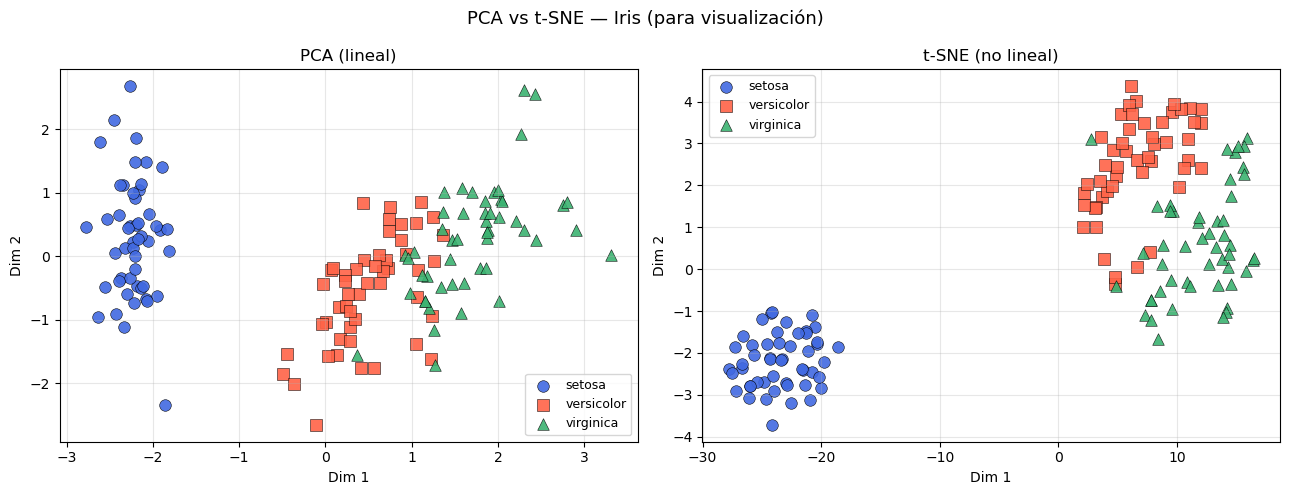

💡 Ambas separan bien las clases en Iris.
   Para datasets más complejos, t-SNE puede revelar estructura local que PCA no captura.
   ⚠️ t-SNE NO es determinista entre ejecuciones (los ejes no tienen significado fijo).


In [9]:
# Comparación visual: PCA vs t-SNE sobre Iris
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(X_scaled)
X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('PCA vs t-SNE — Iris (para visualización)', fontsize=13)

for ax, datos, titulo in zip(axes,
        [X_pca2, X_tsne],
        ['PCA (lineal)', 't-SNE (no lineal)']):
    for i, nombre in enumerate(iris.target_names):
        mask = y == i
        ax.scatter(datos[mask, 0], datos[mask, 1],
                   c=colores_iris[i], marker=formas_iris[i],
                   label=nombre, s=70, edgecolors='black', linewidths=0.4, alpha=0.9)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('💡 Ambas separan bien las clases en Iris.')
print('   Para datasets más complejos, t-SNE puede revelar estructura local que PCA no captura.')
print('   ⚠️ t-SNE NO es determinista entre ejecuciones (los ejes no tienen significado fijo).')


## 🎓 Resumen y Conclusiones

### Mini resumen tipo clase

| Concepto | Clave |
|---|---|
| **¿Para qué?** | Simplificar datos de alta dimensión conservando la información más importante |
| **¿Cómo?** | Encontrar nuevas variables (PC) que maximizan la varianza |
| **Matemática** | Descomposición espectral de la matriz de covarianza |
| **En Python** | `sklearn.decomposition.PCA` |
| **¿Cuántos PC?** | Varianza acumulada ≥ 90–95% (scree plot) |
| **Paso obligatorio** | Escalar con `StandardScaler` **antes** de PCA |
| **No usar PCA para** | Variables categóricas sin codificar, datos con outliers extremos sin tratar |

### ⚠️ Errores comunes

| Error | Por qué es un problema | Solución |
|---|---|---|
| ❌ No escalar | Las features de mayor magnitud dominan las PC | `StandardScaler().fit_transform(X)` |
| ❌ Usar PCA con variables categóricas | Las distancias no tienen sentido semántico | Codificar antes (OneHotEncoder) o usar MCA |
| ❌ Interpretar PC literalmente | Son combinaciones lineales, no variables originales | Analizar loadings con cautela |
| ❌ Aplicar fit en test | Data leakage | Usar `Pipeline` |
| ❌ Forzar k=2 siempre | Se pierde varianza importante | Usar scree plot para elegir k |

### 🚀 ¿Qué sigue?

- 🌐 **UMAP** — alternativa no lineal, más moderna que t-SNE
- 🔍 **Análisis de Componentes Independientes (ICA)** — cuando la independencia estadística importa más que la varianza
- 🧠 **Autoencoders** — reducción no lineal con redes neuronales
- 📊 **LDA (Linear Discriminant Analysis)** — reducción supervisada (usa las etiquetas)

> 📚 **Referencias:**
> - [scikit-learn — PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
> - [scikit-learn — Decomposition](https://scikit-learn.org/stable/modules/decomposition.html)
> - [scikit-learn — t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
> - Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.


---
<br>

**Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER**

Este notebook está licenciado bajo [Creative Commons BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
Podés compartirlo y adaptarlo con atribución y bajo la misma licencia.

*Cristian Pacifico — FCAD/UNER*
